# Visual Anagrams: Generating Multi-View Optical Illusions with Diffusion Models

**<font color='red'>This colab notebook requires a high RAM and V100 GPU runtime, available through Colab Pro.</font> If you would like to use free tier resources, please check out [this notebook](https://colab.research.google.com/github/dangeng/visual_anagrams/blob/main/notebooks/colab_demo_free_tier.ipynb), authored by [Tamizh N](https://github.com/tmzh).**


This colab notebook generates [visual anagrams and other multi-view optical illusions](https://github.com/dangeng/visual_anagrams). These are images that change appearance or identity when transformed, such as by a rotation or a permutation of pixels. Please visit our [website](https://dangeng.github.io/visual_anagrams/) for more details.

By the way, if you generate a particularly good illusion, please send it our way! We'd love to feature it on our website

## DeepFloyd Access

Our method uses [DeepFloyd IF](https://huggingface.co/docs/diffusers/api/pipelines/deepfloyd_if), a pixel-based diffusion model. We do not use Stable Diffusion because latent diffusion models cause artifacts in illusions (see our paper for more details).

Before using DeepFloyd IF, you must accept its usage conditions. To do so:

1. Make sure to have a [Hugging Face account](https://huggingface.co/join) and be logged in.
2. Accept the license on the model card of [DeepFloyd/IF-I-XL-v1.0](https://huggingface.co/DeepFloyd/IF-I-XL-v1.0). Accepting the license on the stage I model card will auto accept for the other IF models.
3. Log in locally by entering your [Hugging Face Hub access token](https://huggingface.co/docs/hub/security-tokens#what-are-user-access-tokens) below, which can be [found here](https://huggingface.co/settings/tokens)

In [ ]:
import diffusers, transformers, huggingface_hub, accelerate, tokenizers
print("diffusers       =", diffusers.__version__)
print("transformers    =", transformers.__version__)
print("huggingface_hub =", huggingface_hub.__version__)
print("accelerate      =", accelerate.__version__)
print("tokenizers      =", tokenizers.__version__)

/usr/local/lib/python3.11/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

diffusers       = 0.24.0
transformers    = 4.35.2
huggingface_hub = 0.19.4
accelerate      = 0.25.0
tokenizers      = 0.15.0


/usr/local/lib/python3.11/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [ ]:
!pip uninstall -y diffusers transformers huggingface_hub accelerate tokenizers peft sentence-transformers datasets gradio hf-xet hf_transfer
!pip install --no-cache-dir --force-reinstall \
  diffusers==0.24.0 \
  transformers==4.35.2 \
  accelerate==0.25.0 \
  huggingface_hub==0.19.4 \
  tokenizers==0.15.0 \
  safetensors==0.4.1 \
  sentencepiece==0.1.99 \
  einops==0.7.0\

!pip uninstall -y torch torchvision torchaudio
!pip install --no-cache-dir --force-reinstall \
  torch==2.10.0 torchvision==0.25.0 torchaudio==2.10.0 \
  --index-url https://download.pytorch.org/whl/cu128

Found existing installation: diffusers 0.34.0
Uninstalling diffusers-0.34.0:
  Successfully uninstalled diffusers-0.34.0
Found existing installation: transformers 4.53.2
Uninstalling transformers-4.53.2:
  Successfully uninstalled transformers-4.53.2
Found existing installation: huggingface-hub 0.33.4
Uninstalling huggingface-hub-0.33.4:
  Successfully uninstalled huggingface-hub-0.33.4
Found existing installation: accelerate 1.8.1
Uninstalling accelerate-1.8.1:
  Successfully uninstalled accelerate-1.8.1
Found existing installation: tokenizers 0.21.2
Uninstalling tokenizers-0.21.2:
  Successfully uninstalled tokenizers-0.21.2
Found existing installation: peft 0.16.0
Uninstalling peft-0.16.0:
  Successfully uninstalled peft-0.16.0
Found existing installation: sentence-transformers 4.1.0
Uninstalling sentence-transformers-4.1.0:
  Successfully uninstalled sentence-transformers-4.1.0
Found existing installation: datasets 2.14.4
Uninstalling datasets-2.14.4:
  Successfully uninstalled dat

Found existing installation: torch 2.12.0
Uninstalling torch-2.12.0:
  Successfully uninstalled torch-2.12.0
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124
Looking in indexes: https://download.pytorch.org/whl/cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 419.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 870.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 551.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 478.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 406.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 465.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 482.

In [ ]:
!pip uninstall -y torch torchvision torchaudio
!pip install --no-cache-dir --force-reinstall \
  torch==2.10.0 torchvision==0.25.0 torchaudio==2.10.0 \
  --index-url https://download.pytorch.org/whl/cu128

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 327.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 802.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 215.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 326.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 344.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 298.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from huggingface_hub import login

try:
    from google.colab import userdata
    token = userdata.get("HF_TOKEN")
except Exception:
    token = None

if token:
    login(token=token)
else:
    login()


Token will not been saved to git credential helper. Pass `add_to_git_credential=True` if you want to set the git credential as well.
Token is valid (permission: fineGrained).
Your token has been saved to /root/.cache/huggingface/token
Login successful


## Install Dependencies

Run the below to install dependencies, including [the `visual_anagrams` repo](https://github.com/dangeng/VisualAnagrams_prerelease) which will do the heavy lifting.

In [ ]:
! pip install -q \
  bitsandbytes \
  mediapy


!pip install -q git+https://github.com/GesusMist/visual_anagrams.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 222.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.0/107.0 kB 25.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## Import Dependencies and Misc Setup

We import packages we need and define some useful functions

In [ ]:
import mediapy as mp

import torch
from diffusers import DiffusionPipeline

from visual_anagrams.views import get_views
from visual_anagrams.samplers import sample_stage_1, sample_stage_2
from visual_anagrams.utils import add_args, save_illusion, save_metadata

device = 'cuda'

def im_to_np(im):
  im = (im / 2 + 0.5).clamp(0, 1)
  im = im.detach().cpu().permute(1, 2, 0).numpy()
  im = (im * 255).round().astype("uint8")
  return im

/usr/local/lib/python3.11/dist-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


## Load Models

This may take a while. We're using the [DeepFloyd IF](https://www.deepfloyd.ai/deepfloyd-if) models, and they are quite big. (If the below code fails, check that you've followed the instructions at the top of this notebook. You must accept the DeepFloyd IF conditions AND log in to huggingface locally).

In [ ]:
# Load DeepFloyd IF stage I
stage_1 = DiffusionPipeline.from_pretrained(
                "DeepFloyd/IF-I-M-v1.0",
                variant="fp16",
                torch_dtype=torch.float16,
              )
stage_1.enable_model_cpu_offload()
stage_1 = stage_1.to(device)

# Load DeepFloyd IF stage II
stage_2 = DiffusionPipeline.from_pretrained(
                "DeepFloyd/IF-II-M-v1.0",
                text_encoder=None,
                variant="fp16",
                torch_dtype=torch.float16,
              )
stage_2.enable_model_cpu_offload()
stage_2 = stage_2.to(device)

# Load DeepFloyd IF stage III
# (which is just Stable Diffusion 4x Upscaler)
stage_3 = DiffusionPipeline.from_pretrained(
                "stabilityai/stable-diffusion-x4-upscaler",
                torch_dtype=torch.float16
            )
stage_3.enable_model_cpu_offload()
stage_3 = stage_3.to(device)

model_index.json:   0%|          | 0.00/604 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.11/dist-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
safety_checker/model.safetensors not found

A mixture of fp16 and non-fp16 filenames will be loaded.
Loaded fp16 filenames:
[text_encoder/pytorch_model.fp16-00002-of-00002.bin, text_encoder/pytorch_model.fp16-00001-of-00002.bin, unet/diffusion_pytorch_model.fp16.bin]
Loaded non-fp16 filenames:
[safety_checker/pytorch_model.bin, watermarker/diffusion_pytorch_model.bin
If this behavior is not expected, please check your folder structure.


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

pytorch_model.fp16-00002-of-00002.bin:   0%|          | 0.00/1.58G [00:00<?, ?B/s]

pytorch_model.fp16-00001-of-00002.bin:   0%|          | 0.00/9.96G [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/587 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.89G [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/221M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

It seems like you have activated model offloading by calling `enable_model_cpu_offload`, but are now manually moving the pipeline to GPU. It is strongly recommended against doing so as memory gains from offloading are likely to be lost. Offloading automatically takes care of moving the individual components vae, text_encoder, tokenizer, unet, low_res_scheduler, scheduler, safety_checker, watermarker, feature_extractor to GPU when needed. To make sure offloading works as expected, you should consider moving the pipeline back to CPU: `pipeline.to('cpu')` or removing the move altogether if you use offloading.


## Prompts and Views

To generate an illusion, we need to provide a list of views and a corresponding list of prompt embeddings. We start with the list of views, which we can get by passing a list of strings to the `get_views` function. For a list of views and their implementation see the `views.py` file. Views inherit from the `BaseView` class, so you can implement your own views if you want.

### The Art of Choosing Prompts

**Choosing prompts for illusions can be fairly tricky and unintuitive**. Many prompts simply won't make for good illusions, because they are too hard. Here are some tips:

- Styles such as "a photo of" tend to be harder as the constraint of realism is fairly difficult (but this doesn't mean they can't work!).
- Conversely, styles such as "an oil painting of" seem to do better because there's more freedom to how it can be depicted and interpreted.
- In a similar vein, subjects that allow for high degrees of flexibility in depiction tend to be good. For example, prompts such as "houseplants" or "wine and cheese" or "a kitchen"
- But be careful the subject is still easily recognizable. Illusions are much better when they are instantly understandable.
- Faces often make for very good "hidden" subjects. This is probably because the human visual system is particularly adept at picking out faces. For example, "an old man" or "marilyn monroe" tend to be good subjects.
- Perhaps a bit evident, but 3 view and 4 view illusions are considerably more difficult to get to work.
- Intuition and reasoning works less often than you would expect. Prompts that you think would work great often work poorly, and vice versa. So exploration is key.

In [30]:
# UNCOMMENT ONE OF THESE

#views = get_views(['identity', 'rotate_180'])
#views = get_views(['identity', 'rotate_cw'])
# views = get_views(['identity', 'rotate_ccw'])
# views = get_views(['identity', 'flip'])
#views = get_views(['identity', 'negate'])
#views = get_views(['identity', 'skew'])
#views = get_views(['identity', 'patch_permute'])
# views = get_views(['identity', 'pixel_permute'])
views = get_views(['identity', 'inner_circle_failure'])
# views = get_views(['identity', 'square_hinge'])
# views = get_views(['identity', 'jigsaw'])
#views = get_views(['identity', 'strips'])
#views = get_views(['identity', 'scale'])
#views = get_views(['low_pass', 'high_pass'], view_args=['1.5', '1.5'])

Next, we need text prompts. We can specify a list of strings, and pass it into the `encode_prompt` function.

In [27]:
# Feel free to change me:
prompt_1 = 'paint of snow mountain'
prompt_2 = 'paint of a horse'

# Embed prompts using the T5 model
prompts = [prompt_1, prompt_2]
prompt_embeds = [stage_1.encode_prompt(prompt) for prompt in prompts]
prompt_embeds, negative_prompt_embeds = zip(*prompt_embeds)
prompt_embeds = torch.cat(prompt_embeds)
negative_prompt_embeds = torch.cat(negative_prompt_embeds)  # These are just null embeds

## Generate Illusions

Now, we can sample illusions by denoising all views at once. The `sample_stage_1` function does this and generates a $64 \times 64$ image. The `sample_stage_2` function upsamples the resulting image while denoising all views, and generates a $256 \times 256$ image.

100%|██████████| 30/30 [00:00<00:00, 46.01it/s]


,

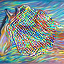
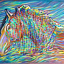

In [31]:
image_64 = sample_stage_1(stage_1,
                          prompt_embeds,
                          negative_prompt_embeds,
                          views,
                          num_inference_steps=30,
                          guidance_scale=10.0,
                          reduction='mean',
                          generator=torch.Generator(device=device).manual_seed(22),
                          )
mp.show_images([im_to_np(view.view(image_64[0])) for view in views])

100%|██████████| 30/30 [00:02<00:00, 14.65it/s]


,

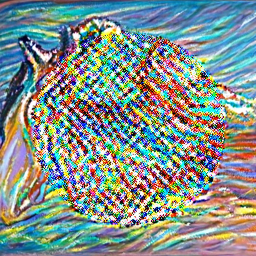
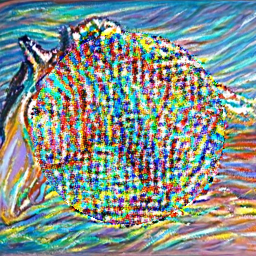

In [32]:
image_256 = sample_stage_2(stage_2,
                           image_64,
                           prompt_embeds,
                           negative_prompt_embeds,
                           views,
                           num_inference_steps=30,
                           guidance_scale=10.0,
                           reduction='mean',
                           noise_level=50,
                           generator=None)
mp.show_images([im_to_np(view.view(image_256[0])) for view in views])

/usr/local/lib/python3.11/dist-packages/diffusers/image_processor.py:339: FutureWarning: Passing `image` as torch tensor with value range in [-1,1] is deprecated. The expected value range for image tensor is [0,1] when passing as pytorch tensor or numpy Array. You passed `image` with value range [-1.0,1.0]
  warnings.warn(


  0%|          | 0/75 [00:00<?, ?it/s]

,

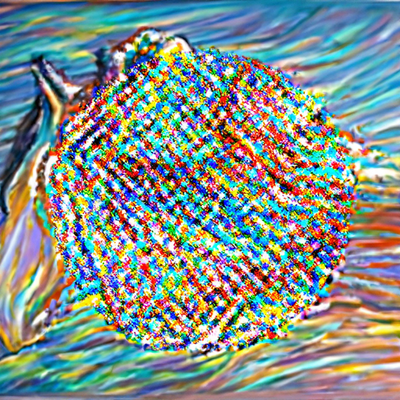
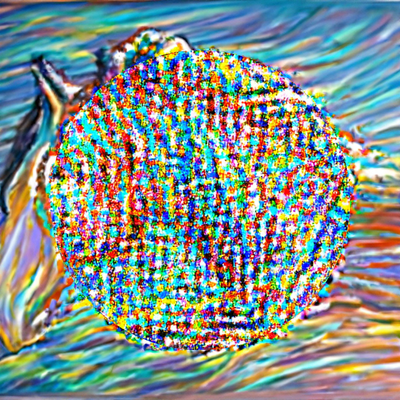

In [ ]:
image_1024 = stage_3(
                prompt=prompts[0],  # Note this is a string, and not an embedding
                image=image_256,
                noise_level=0,
                output_type='pt',
                generator=None).images
image_1024 = image_1024 * 2 - 1

# Limit display size, otherwise it's too large for most screens
mp.show_images([im_to_np(view.view(image_1024[0])) for view in views], width=400)

## Animating the Illusion

We will use the `animate_two_view` function to make a video of the illusion. This function takes in a PIL image of the illusion, a `view` object (which should implement `make_frame`), and animates the transformation defined by the `view`. We will save the video to `save_video_path`.

The animation function works for all three sizes: `image_64`, `image_256`, or `image_1024` (thought it takes about a minute for size `1024`).

In [ ]:
from visual_anagrams.animate import animate_two_view
import torchvision.transforms.functional as TF

##############################
# UNCOMMENT FOR DESIRED SIZE #
##############################
#image = image_64
#image = image_256
image = image_1024

# Get size
im_size = image.shape[-1]
frame_size = int(im_size * 1.5)

# Make save path
save_video_path = './animation.mp4'

# Convert to PIL
pil_image = TF.to_pil_image(image[0] / 2. + 0.5)

# Make the animation
animate_two_view(
            pil_image,
            views[1], # Use the non-identity view to transform
            prompt_1,
            prompt_2,
            save_video_path=save_video_path,
            hold_duration=120,
            text_fade_duration=10,
            transition_duration=45,
            im_size=im_size,
            frame_size=frame_size,
        )

# Display the video (using max width of 600 so will fit on most screens)
mp.show_video(mp.read_video(save_video_path), fps=30, width=min(600, frame_size))

Making frames...


100%|██████████| 45/45 [00:00<00:00, 120.55it/s]


Making video...


This browser does not support the video tag.
